# Final project log analysis

This notebook is adapted for the `final_project_Jeremy` branch. The training checkpoints store the scalar CMA-ES fitness directly. Terrain-specific plots are obtained by re-evaluating saved `x_best.npy` checkpoints on Flat, Ice, and Hill.


In [42]:
from pathlib import Path
import os

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams["axes.grid"] = True


## Select a result folder

By default this uses the latest `results/*_final_test` folder. Set `RESULT_DIR` manually if you want another run.


In [43]:
result_dirs = sorted(Path("results").glob("*_final_test"))
if not result_dirs:
    raise FileNotFoundError("No results/*_final_test folders found")

print("Available runs:")
for i, run_dir in enumerate(result_dirs):
    print(f"{i:2d}: {run_dir}")

# Change this line if you want a specific run, for example:
# RESULT_DIR = Path("results/2026-05-15_19-10-13_final_test")
RESULT_DIR = result_dirs[3]
print(f"\nUsing: {RESULT_DIR}")


Available runs:
 0: results/2026-05-14_19-47-51_final_test
 1: results/2026-05-14_21-33-26_final_test
 2: results/2026-05-15_19-10-13_final_test
 3: results/2026-05-16_21-31-47_final_test
 4: results/2026-05-17_23-09-21_final_test

Using: results/2026-05-16_21-31-47_final_test


## Scalar CMA-ES fitness over generations

This is the value the optimizer actually used in this branch. In the current training code it corresponds to `min(flat, ice, hill) + 0.2 * mean(flat, ice, hill)` for each individual.


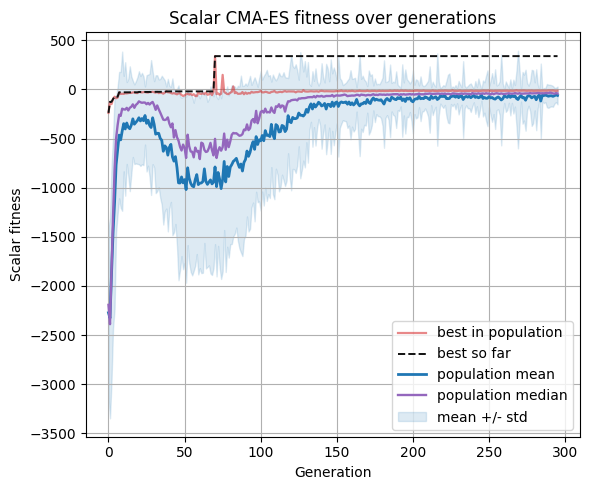

In [44]:
def load_full_scalar_fitness(result_dir: Path):
    full_f_path = result_dir / "full_f.npy"
    if full_f_path.exists():
        full_f = np.load(full_f_path, allow_pickle=True)
        full_f = np.asarray(full_f, dtype=float)
        if full_f.ndim == 1:
            full_f = full_f[:, None]
        generations = np.arange(full_f.shape[0])
        return generations, full_f

    checkpoint_dirs = sorted(
        [p for p in result_dir.iterdir() if p.is_dir() and p.name.isdigit()],
        key=lambda p: int(p.name),
    )
    generations = []
    rows = []
    for ckpt_dir in checkpoint_dirs:
        f_path = ckpt_dir / "f.npy"
        if not f_path.exists():
            continue
        generations.append(int(ckpt_dir.name))
        rows.append(np.asarray(np.load(f_path, allow_pickle=True), dtype=float).reshape(-1))
    if not rows:
        raise FileNotFoundError(f"No f.npy or full_f.npy found in {result_dir}")
    return np.asarray(generations), np.vstack(rows)

scalar_generations, scalar_fitness = load_full_scalar_fitness(RESULT_DIR)

scalar_mean = scalar_fitness.mean(axis=1)
scalar_std = scalar_fitness.std(axis=1)
scalar_median = np.median(scalar_fitness, axis=1)
scalar_best = scalar_fitness.max(axis=1)
scalar_best_so_far = np.maximum.accumulate(scalar_best)

fig, ax = plt.subplots()
ax.plot(scalar_generations, scalar_best, color="#d62728", linewidth=1.6, alpha=0.55, label="best in population")
ax.plot(scalar_generations, scalar_best_so_far, color="#111111", linewidth=1.4, linestyle="--", label="best so far")
ax.plot(scalar_generations, scalar_mean, color="#1f77b4", linewidth=2, label="population mean")
ax.plot(scalar_generations, scalar_median, color="#9467bd", linewidth=1.7, label="population median")
ax.fill_between(
    scalar_generations,
    scalar_mean - scalar_std,
    scalar_mean + scalar_std,
    color="#1f77b4",
    alpha=0.15,
    label="mean +/- std",
)
ax.set_title("Scalar CMA-ES fitness over generations")
ax.set_xlabel("Generation")
ax.set_ylabel("Scalar fitness")
ax.legend()
fig.tight_layout()


## Re-evaluate saved best robots by terrain

The checkpoint files only store the scalar fitness, not the three terrain rewards. This cell re-evaluates saved `x_best.npy` checkpoints on Flat, Ice, and Hill, then plots:

- summed reward across terrains, for comparison with your friend's plot
- minimum terrain reward, which is the best generalist indicator
- branch scalar reward: `min + 0.2 * mean`
- individual Flat / Ice / Hill rewards

The result is cached in the selected result folder so rerunning the notebook is fast.


In [32]:
import gymnasium as gym
from final_project_train import FinalWorld, generalist_scalar_fitness

# These should match the run you want to analyse. Lower N_REPEATS for a quick preview.
N_REPEATS = 4
N_STEPS = 500
EVAL_EVERY = 5      # evaluate every N generations/checkpoints
RECOMPUTE = False   # set True to ignore the cached terrain scores

TERRAINS = [
    ("Flat", "FlatEnv-v0", "flat_world_file"),
    ("Ice", "IceEnv-v0", "ice_world_file"),
    ("Hill", "HillEnv-v0", "hill_world_file"),
]

def checkpoint_dirs(result_dir: Path, every: int | None = None):
    dirs = sorted(
        [p for p in result_dir.iterdir() if p.is_dir() and p.name.isdigit()],
        key=lambda p: int(p.name),
    )
    if every is None:
        return dirs
    return [p for p in dirs if int(p.name) % every == 0]

def eval_env_seq(world, env_id: str, world_file: str, n_repeats: int, n_steps: int) -> float:
    rewards = []
    for rep in range(n_repeats):
        env = gym.make(env_id, robot_path=world_file, max_episode_steps=n_steps)
        obs, _ = env.reset(seed=rep)
        world.controller.reset_controller(batch_size=1)
        total = 0.0
        for _ in range(n_steps):
            ctrl_obs = world.sensor_fn(obs) if world.sensor_fn is not None else obs
            action = world.controller.get_action(ctrl_obs)
            if getattr(action, "ndim", 0) > 1:
                action = action.squeeze(0)
            obs, reward, terminated, truncated, _ = env.step(action)
            total += float(reward)
            if terminated or truncated:
                break
        env.close()
        rewards.append(total)
    return float(np.mean(rewards))

def evaluate_best_checkpoints(result_dir: Path, every: int, n_repeats: int, n_steps: int, recompute: bool = False):
    cache_path = result_dir / f"analysis_terrain_scores_every{every}_r{n_repeats}_s{n_steps}.npz"
    if cache_path.exists() and not recompute:
        cached = np.load(cache_path)
        return cached["generations"], cached["terrain_scores"]

    world = FinalWorld()
    generations = []
    terrain_scores = []
    dirs = checkpoint_dirs(result_dir, every=every)

    for n, ckpt_dir in enumerate(dirs, start=1):
        x_best_path = ckpt_dir / "x_best.npy"
        if not x_best_path.exists():
            continue

        generation = int(ckpt_dir.name)
        x_best = np.load(x_best_path, allow_pickle=True)
        world.update_robot_xml(x_best)

        scores = []
        for _, env_id, world_file_attr in TERRAINS:
            scores.append(
                eval_env_seq(
                    world,
                    env_id,
                    getattr(world, world_file_attr),
                    n_repeats=n_repeats,
                    n_steps=n_steps,
                )
            )

        generations.append(generation)
        terrain_scores.append(scores)
        print(f"{n:3d}/{len(dirs)} gen {generation:4d}: flat={scores[0]:8.2f} ice={scores[1]:8.2f} hill={scores[2]:8.2f}")

    generations = np.asarray(generations, dtype=int)
    terrain_scores = np.asarray(terrain_scores, dtype=float)
    np.savez(cache_path, generations=generations, terrain_scores=terrain_scores)
    return generations, terrain_scores

generations, terrain_scores = evaluate_best_checkpoints(
    RESULT_DIR,
    every=EVAL_EVERY,
    n_repeats=N_REPEATS,
    n_steps=N_STEPS,
    recompute=RECOMPUTE,
)

terrain_sum = terrain_scores.sum(axis=1)
terrain_min = terrain_scores.min(axis=1)
terrain_mean = terrain_scores.mean(axis=1)
terrain_scalar = np.asarray([generalist_scalar_fitness(row) for row in terrain_scores])

fig, ax = plt.subplots()
ax.plot(generations, terrain_sum, marker="o", linewidth=2, color="#ff7f0e", label="sum(flat, ice, hill)")
ax.plot(generations, terrain_min, marker="o", linewidth=2, color="#d62728", label="min(flat, ice, hill)")
ax.plot(generations, terrain_scalar, marker="o", linewidth=2, color="#2ca02c", label="generalist scalar: min + 0.2 * mean")
ax.set_title("Best-so-far robot reward over generations")
ax.set_xlabel("Generation")
ax.set_ylabel("Reward")
ax.legend()
fig.tight_layout()

fig, ax = plt.subplots()
colors = ["#1f77b4", "#17becf", "#9467bd"]
for idx, (label, _, _) in enumerate(TERRAINS):
    ax.plot(generations, terrain_scores[:, idx], marker="o", linewidth=2, color=colors[idx], label=label)
ax.set_title("Best-so-far robot reward per terrain")
ax.set_xlabel("Generation")
ax.set_ylabel("Reward")
ax.legend()
fig.tight_layout()


ValueError: too many values to unpack (expected 2)